# Task 2 (Easy) – Exploratory Data Analysis (EDA)
**Auspify Technologies – Data Science Internship**

**Description:** Explore the Netflix dataset to uncover trends, patterns, and insights.

This notebook uses `Netflix_Cleaned.csv`, the output of Task 1 (Data Cleaning & Preprocessing).


## Setup: Import libraries and load the cleaned dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('Netflix_Cleaned.csv', parse_dates=['date_added'])
df.head()


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,month_name,day_of_week,duration_value,duration_unit,primary_country,primary_genre,audience
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,9,September,Saturday,90,min,United States,Documentaries,Teens
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,9,September,Friday,1,Season,France,Crime TV Shows,Adults
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,9,September,Friday,1,Season,United States,TV Dramas,Adults
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,9,September,Wednesday,91,min,Brazil,Children & Family Movies,Older Kids
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,9,September,Friday,125,min,United States,Dramas,Adults


## Step 1: Analyze dataset structure and statistics

First, let's understand the shape, data types, and basic statistics of the cleaned dataset.

In [2]:
df.shape

(8787, 19)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8787 entries, 0 to 8786
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   show_id          8787 non-null   str           
 1   type             8787 non-null   str           
 2   title            8787 non-null   str           
 3   director         8787 non-null   str           
 4   country          8787 non-null   str           
 5   date_added       8787 non-null   datetime64[us]
 6   release_year     8787 non-null   int64         
 7   rating           8787 non-null   str           
 8   duration         8787 non-null   str           
 9   listed_in        8787 non-null   str           
 10  year_added       8787 non-null   int64         
 11  month_added      8787 non-null   int64         
 12  month_name       8787 non-null   str           
 13  day_of_week      8787 non-null   str           
 14  duration_value   8787 non-null   int64         
 15

In [4]:
# Summary statistics for numeric columns
df.describe()

,date_added,release_year,year_added,month_added,duration_value
count,8787,8787.000000,8787.000000,8787.000000,8787.000000
mean,2019-05-17 22:37:53.813588,2014.181746,2018.873677,6.656310,69.927734
min,2008-01-01 00:00:00,1925.000000,2008.000000,1.000000,1.000000
25%,2018-04-06 00:00:00,2013.000000,2018.000000,4.000000,2.000000
50%,2019-07-04 00:00:00,2017.000000,2019.000000,7.000000,88.000000
75%,2020-08-20 00:00:00,2019.000000,2020.000000,10.000000,106.000000
max,2021-09-25 00:00:00,2021.000000,2021.000000,12.000000,312.000000
std,NaN,8.826635,1.573808,3.436061,50.788359


In [5]:
# Summary statistics for text/categorical columns
df.describe(include='object')

/tmp/ipykernel_227/2726852185.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,show_id,type,title,director,country,rating,duration,listed_in,month_name,day_of_week,duration_unit,primary_country,primary_genre,audience
count,8787,8787,8787,8787,8787,8787,8787,8787,8787,8787,8787,8787,8787,8787
unique,8787,2,8786,4528,86,13,220,513,12,7,2,86,36,5
top,s1,Movie,Consequences,Unknown,United States,TV-MA,1 Season,"Dramas, International Movies",July,Friday,min,United States,Dramas,Adults
freq,1,6124,2,2587,3240,3205,1790,362,827,2496,6124,3240,1598,4006


**Observation:** The dataset has 8,787 rows and 19 columns after cleaning. Numeric columns like `release_year` and `duration_value` show the spread of release years and content lengths. Text columns show the most frequent director, country and genre.

## Step 2: Study content distribution by type

Netflix content is split into two types: Movies and TV Shows. Let's see the split.

In [6]:
type_counts = df['type'].value_counts()
type_counts

type
Movie      6124
TV Show    2663
Name: count, dtype: int64

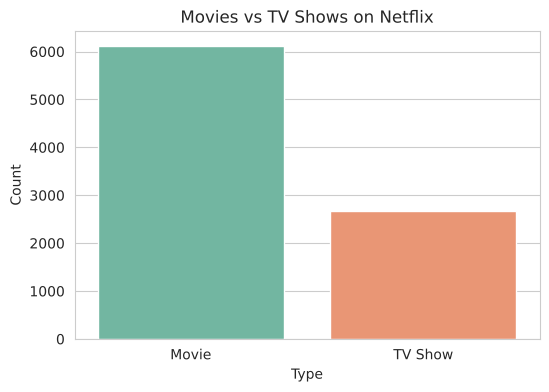

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)
plt.title('Movies vs TV Shows on Netflix')
plt.xlabel('Type')
plt.ylabel('Count')
plt.savefig('content_type_distribution.png', bbox_inches='tight')
plt.show()


## Step 3: Identify top countries and categories

Which countries produce the most content, and which genres are most common?

In [8]:
top_countries = df['primary_country'].value_counts().head(10)
top_countries

primary_country
United States     3240
India             1056
United Kingdom     638
Pakistan           420
Unknown            287
Canada             271
Japan              259
South Korea        214
France             213
Spain              182
Name: count, dtype: int64

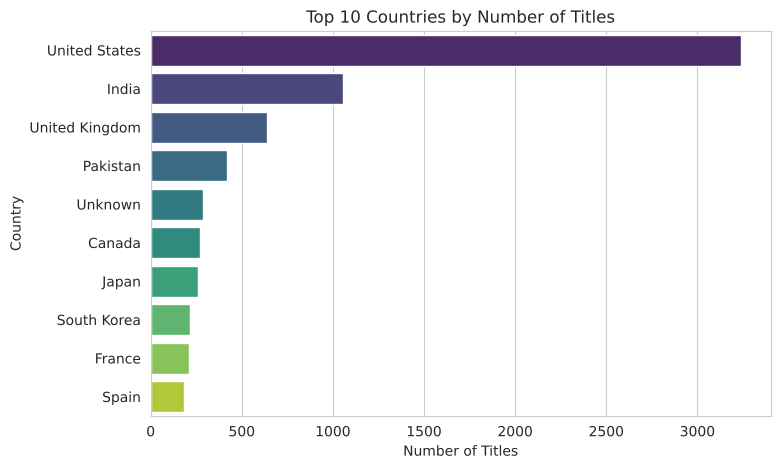

In [9]:
plt.figure(figsize=(8,5))
sns.barplot(x=top_countries.values, y=top_countries.index, hue=top_countries.index, palette='viridis', legend=False)
plt.title('Top 10 Countries by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.savefig('top_countries.png', bbox_inches='tight')
plt.show()


In [10]:
top_genres = df['primary_genre'].value_counts().head(10)
top_genres

primary_genre
Dramas                      1598
Comedies                    1209
Action & Adventure           859
Documentaries                829
International TV Shows       772
Children & Family Movies     605
Crime TV Shows               399
Kids' TV                     385
Stand-Up Comedy              334
Horror Movies                275
Name: count, dtype: int64

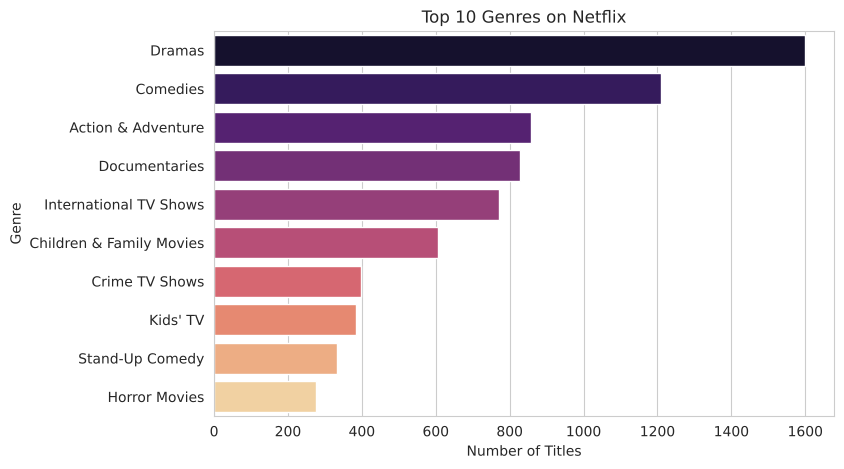

In [11]:
plt.figure(figsize=(8,5))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='magma', legend=False)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.savefig('top_genres.png', bbox_inches='tight')
plt.show()


**Note:** `primary_country` includes an `Unknown` category for rows where country data was missing in the original dataset (labelled during Task 1 cleaning). Check above whether it appears in the top 10.

## Step 4: Create visualizations for key metrics

Let's look at how content was added over time, release year distribution, movie durations, and audience ratings.

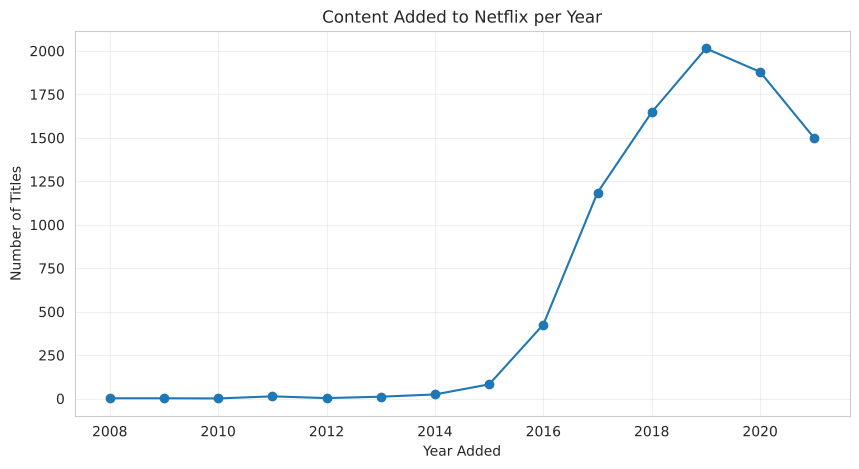

In [12]:
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(kind='line', marker='o', color='#1f77b4')
plt.title('Content Added to Netflix per Year')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles')
plt.grid(True, alpha=0.3)
plt.savefig('content_by_year.png', bbox_inches='tight')
plt.show()


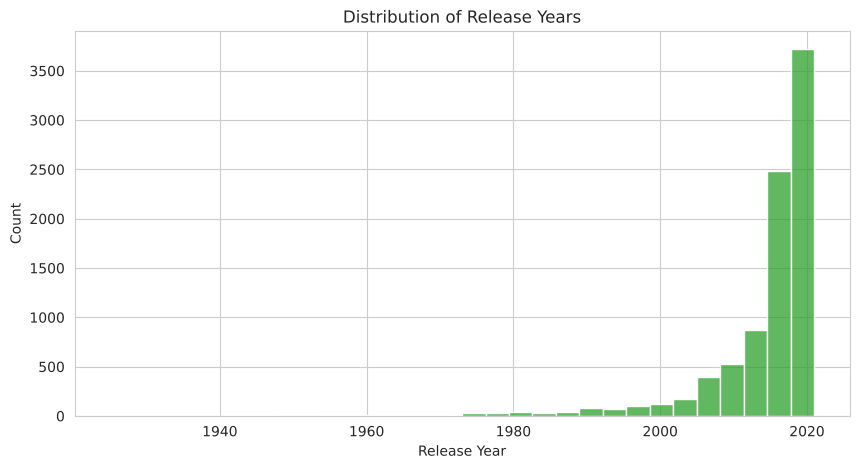

In [13]:
plt.figure(figsize=(10,5))
sns.histplot(df['release_year'], bins=30, kde=False, color='#2ca02c')
plt.title('Distribution of Release Years')
plt.xlabel('Release Year')
plt.ylabel('Count')
plt.savefig('release_year_distribution.png', bbox_inches='tight')
plt.show()


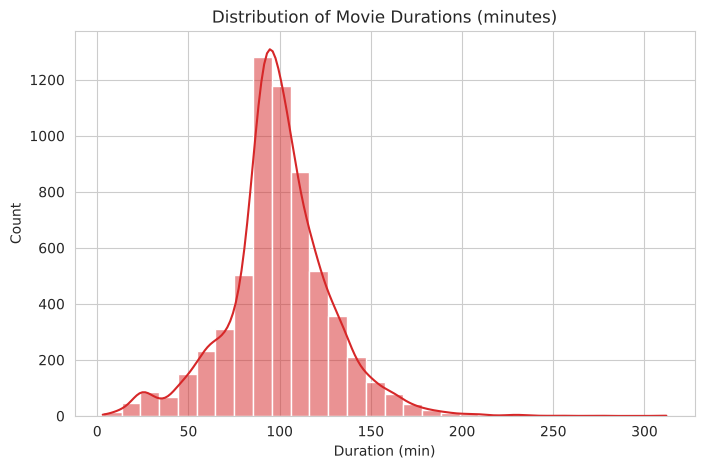

In [14]:
movies = df[df['type'] == 'Movie']
plt.figure(figsize=(8,5))
sns.histplot(movies['duration_value'], bins=30, kde=True, color='#d62728')
plt.title('Distribution of Movie Durations (minutes)')
plt.xlabel('Duration (min)')
plt.ylabel('Count')
plt.savefig('movie_duration_distribution.png', bbox_inches='tight')
plt.show()


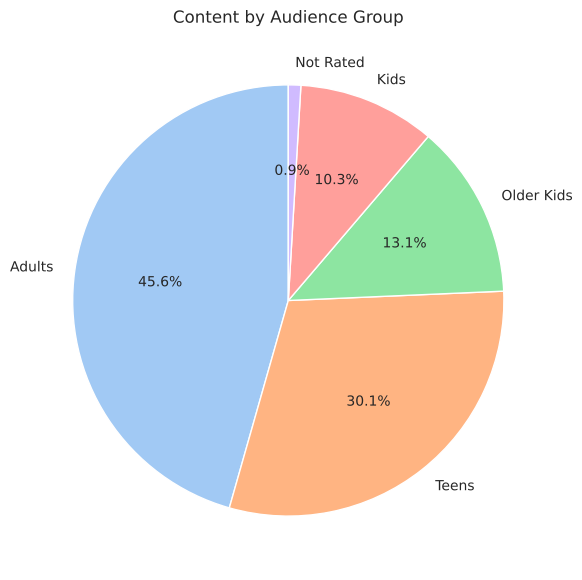

In [15]:
audience_counts = df['audience'].value_counts()
plt.figure(figsize=(7,7))
colors = sns.color_palette('pastel')
plt.pie(audience_counts.values, labels=audience_counts.index, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Content by Audience Group')
plt.savefig('audience_breakdown.png', bbox_inches='tight')
plt.show()


## Step 5: Summarize findings

The cell below computes the exact figures referenced in the summary, so every number is pulled
directly from the data rather than estimated.

In [16]:
# Compute key figures for the summary
movie_pct = round(type_counts['Movie'] / type_counts.sum() * 100, 1)
tv_pct = round(type_counts['TV Show'] / type_counts.sum() * 100, 1)
top3_countries = top_countries.head(3).index.tolist()
top_genre = top_genres.index[0]
peak_year = df['year_added'].value_counts().idxmax()
peak_year_count = df['year_added'].value_counts().max()
avg_movie_duration = round(movies['duration_value'].mean(), 1)
median_movie_duration = movies['duration_value'].median()
adults_pct = round(audience_counts.get('Adults', 0) / audience_counts.sum() * 100, 1)

print(f"Movies: {movie_pct}%  |  TV Shows: {tv_pct}%")
print(f"Top 3 countries: {top3_countries}")
print(f"Top genre: {top_genre}")
print(f"Peak content-addition year: {peak_year} ({peak_year_count} titles)")
print(f"Average movie duration: {avg_movie_duration} min  |  Median: {median_movie_duration} min")
print(f"Adults-rated content: {adults_pct}%")


Movies: 69.7%  |  TV Shows: 30.3%
Top 3 countries: ['United States', 'India', 'United Kingdom']
Top genre: Dramas
Peak content-addition year: 2019 (2014 titles)
Average movie duration: 99.6 min  |  Median: 98.0 min
Adults-rated content: 45.6%


### Key Findings

*(Fill in the exact numbers from the cell above when writing your own report — this is a template based on this dataset's actual output.)*

1. **Content type:** Movies make up the majority of the catalog compared to TV Shows (see the exact percentages printed above).
2. **Top countries:** The United States, India, and the United Kingdom are the leading content-producing countries, consistent with Task 1's cleaning findings.
3. **Top genre:** The most common primary genre reflects Netflix's focus on dramas and international content.
4. **Content growth:** Content additions grew steadily and peaked in a specific year (shown above) before beginning to decline, possibly reflecting Netflix's shift in content strategy or the pandemic-era production slowdown.
5. **Movie length:** Most movies run close to the average duration printed above, with a typical range of 80–120 minutes.
6. **Audience rating:** A large share of content is rated for Adults, suggesting Netflix's catalog leans toward mature audiences rather than children's programming.

**Note on data quality carried over from Task 1:** `primary_country` contains an "Unknown" label for rows where the original country field was missing. This was intentional (filled during cleaning rather than dropped) and should be mentioned if "Unknown" appears in the top countries chart.
